# Lesson154 · Portfolio synthesis: make every claim auditable

Student lab · PROVIDED / TODO / CHECK / EXIT. The default lane is a standalone CPU replay of real author evidence. Complete the three functions before running the final report. It does not train models, download datasets, or use cloud services. Source/target provenance remains bounded by the embedded ledgers. Offline execution needs numpy and IPython; standard Jupyter environments provide them.

In [ ]:
# PROVIDED: CPU-only replay. Requires Python3.10+ and numpy; no network at runtime.
# Tested dependencies are recorded in labs/_execution_l154_results.json.
import base64,copy,gzip,hashlib,json,math,statistics,tempfile,zlib
from pathlib import Path
import numpy as np
from IPython.display import display,Markdown


In [ ]:
# PROVIDED: author evidence transport. The visible replay below consumes these bytes.
# A fresh temporary directory prevents overwriting your workspace.
MANIFEST={'experiment': 'L154 RelBench portfolio evidence replay', 'freeze_date': '2026-10-01', 'boundary': 'Hash integrity of captured inputs; no historical-identity claim.', 'files': {'evidence/l151/frozen.json': 'bc94f4831f1ac9c450f41e1bc7a38dcfa7688a606c04ef4b81c7283b5eed467d', 'evidence/l151/prepared/queries.npz': 'c6f389fa158af01679b3731b7ab7daa98151c4e878dbca015ca8acde81c69a22', 'evidence/l151/prepared/task_audit.json': '9295489f0c660840660793b7eb2583e3d885ccc85cfdf73e2049738418803c74', 'evidence/l151/ref-0/predictions.npz': '51d0ce3987294ccda80c6bcb6b584c54604558365a5b5f38f1c9fd79def664c6', 'evidence/l151/ref-0/result.json': '02ef22fd0530672abc865b97b5da4614bbeba9ba842eecd8ae347678640d2c0b', 'evidence/l151/ref-1/predictions.npz': '7a903df9895bda841fd43f4560f4e37b8cd095bdfec3e4b6451aa056463f58fd', 'evidence/l151/ref-1/result.json': '5d41f9ddddb0b0ca5ae87bdedd72867af04323357bfbfb50a12690e841280ea8', 'evidence/l151/ref-2/predictions.npz': '35461ada128f5c814472c6970b859e1dc67ab816ec10fa77b965864b1c658a18', 'evidence/l151/ref-2/result.json': 'a50d3972a70b291b696dc9d7549ad3d8fcdafc09111f875ccbe3d1dc906ad886', 'evidence/l151/ref-3/predictions.npz': 'e7ec1ab718e995fa85c1d7b445f531da6e62e98a72030e6c1f5f416b5c3ec9fe', 'evidence/l151/ref-3/result.json': '069fa21a53b5fd7e09c4e69df25da3e2730d8b116b90ffcf0912765e741dc637', 'evidence/l151/ref-4/predictions.npz': '2fc5bba0d33e05d6e87f3dacdf63bfc89a7b75d7c3891eea60b4a50aad0933c6', 'evidence/l151/ref-4/result.json': '7e498a8110d62328ab6ce3fc91e5caaed6497220d782aa74f087284ffd22a874', 'evidence/l151/selected-10/predictions.npz': 'fba90fafdd4da1d07570aeceb9e3d9009851c94f0a23b30b034c612506055246', 'evidence/l151/selected-10/result.json': 'ce0066cb9932d9af01017330514e6f851ece6847d338322ad062248b4dc39313', 'evidence/l151/selected-11/predictions.npz': '209eb51358582b3f471093e7a9be6a2d71e6cc306d28219b0a88190f27ff1be5', 'evidence/l151/selected-11/result.json': '267b59ce26a9c4ea80d4a845f19d9e4b688aa2b2b5e48710562041e3201d5e83', 'evidence/l151/selected-12/predictions.npz': '2e0d1c2f20c3e33259c902b9d71c61d76b38efc8544dd286547d90dc964573fb', 'evidence/l151/selected-12/result.json': '8d3e977580e166a4677b9fe87266be50bbbde90a98bc7c49b1e89cbd8dc666d4', 'evidence/l151/selected-13/predictions.npz': '48903a0724d910a10fe69b4756f85927956d320dfcd7ff9935bce0fcc38196f5', 'evidence/l151/selected-13/result.json': 'f9876c1a76104dfeede92eec60d75812752b9dd3750e9888cfefb81d85ff6714', 'evidence/l151/selected-14/predictions.npz': 'af4b726548a266fba5292edb1baf481d041dcf0f2a079052d0c8539fc3da88e0', 'evidence/l151/selected-14/result.json': '145aa85644df8a2616402df0fe28496689d413619256c7e988afa10f35a576b6', 'evidence/l152/label-audit.json': '4b8bfe28e9f0a5d3b1b35bdeb365f1b32f01f355f940de40e8f53fc983f82c23', 'evidence/l152/paper/seed-0/completed.json': 'a40f8634852919e411c073f43a00b5af05b4f1c6d691f399f20f7b2d30286810', 'evidence/l152/paper/seed-0/predictions.npz': '37935143a9d89f1e4324fae5b47cd4a09b1201f73e25eef98727737fdd4cbf78', 'evidence/l152/paper/seed-0/result.json': 'fd3caf154e09b56d4e1cc09177b2ff34c483d1f8698b8673099df0434acfa231', 'evidence/l152/paper/seed-0/temporal-audit.json': 'd58355173c7eeb0ca8a16bb7109318cecc9c2994db1e5243a83ea6bf16e5b689', 'evidence/l152/paper/seed-1/completed.json': '372d12baaf4ba4ef5037caf3fe48d437ab79f60a17f466e53761e99e2ab235f3', 'evidence/l152/paper/seed-1/predictions.npz': '40969d6664e2541106013b8d86f751fbbeaff031234c2e94b68a3db7fa792d5a', 'evidence/l152/paper/seed-1/result.json': '95b03b18698e798d657558611c9bf7c4e6b0f64858561a0800610fb97d391d9a', 'evidence/l152/paper/seed-1/temporal-audit.json': 'e78947ded054e6fb6538cb0df20e1a3215e579d3f22a5ceb1bb81a7e02600a68', 'evidence/l152/paper/seed-2/completed.json': '9049cb47193e4203cfa7d2491efa1917496b33b0c7f0d19a98e6a9216bcf7ef5', 'evidence/l152/paper/seed-2/predictions.npz': '60827c6d935ea8e67db3f94ba9886c4133e275ed2c9791c9e92fee2639a9dcb9', 'evidence/l152/paper/seed-2/result.json': 'bd45cc4074384b3cfe8e9d0813329c99463f2ac9ad52fe9678778afb25c7e297', 'evidence/l152/paper/seed-2/temporal-audit.json': '58245fa0615fcbc80e831af8df6a66fb31e2876d8a8cdb47f427edfd9cd6ec34', 'evidence/l152/paper/seed-3/completed.json': 'd38061eb254b0880b46f028868ad6b79dc7049fd7fedebcbe3fe41a07b86a6c7', 'evidence/l152/paper/seed-3/predictions.npz': 'f9da76d067653c22aad42953447d66c941e57a05327888cb64c57c4aa1299c81', 'evidence/l152/paper/seed-3/result.json': '64a568e5c68fe1e10b616982c91922a4735afe3d1371a361c19dc70d23660c1d', 'evidence/l152/paper/seed-3/temporal-audit.json': 'c445bc48111908707d812e711bb4b73310497f70bec7dbf484486b26fee3497f', 'evidence/l152/paper/seed-4/completed.json': '969bdc86f6c5e29e5d0c03be3f63dac829e10dbd271b54949ac0df74fab0d53c', 'evidence/l152/paper/seed-4/predictions.npz': 'da898b061ffdaf4214c7ac51de23f9377aac0e1215fae2a3da2068aca9e9c9a2', 'evidence/l152/paper/seed-4/result.json': '196cd9f47fabb06a5714deeb906f82b8fd72ec3ad848992c429301de7d4306ef', 'evidence/l152/paper/seed-4/temporal-audit.json': '0aa93e28e719f61b62544b731debbfe20de095e56a9f6863cf1c5d618fc75dfa', 'evidence/l153/cost-decision.json': 'bbb083b02dd531cdb9d248a99d0e72e8e738fcc404bf59c7e036979e7c08567f', 'evidence/l153/pilot/predictions.npz': 'f1e5a07e60262d30ff5a7713ad6151f91f3507683a328ad267ef6aa2257b9555', 'evidence/l153/pilot/result.json': 'f0041ce48f981052ac0838eff93ba9260afaea1a84a4a60c32d4f67bc08c7677', 'evidence/l153/prepared/val-truth.json.gz': '7aa1f02a593e2d0b5c85bf9b2fb92eaa9684dbb4fe14aaef353ac42e2ea11d5c', 'evidence/l154/published-context.json': 'd57df198c73e27cc649dde699a671ff6b253a4840d3e912776dc5b4bbacf92d6', 'evidence/l154/published-tables.html': '0c0b8dca49e50de2ad796e00e7f1e06c1754f9aa5fc8bdcfecef5c510ac6068c', 'sources/l151/manifest.json': 'fd04e44295d839301a1edf83111819146bfe4f0d5b81294edfa556fbd1e37b79', 'sources/l151/paper.html': 'f933604d45fa863819902b13f5b65f7ea684c7f9f9b74a61f2229c7c2f73f1fc', 'sources/l151/protocol.json': '34aafcc9902737e5cae697207db9f8d67d28b499631602f146c6b772f7798299', 'sources/l152/protocol.json': 'a8f46e521e579d19c8d82592292d63e07aecef02031f3e50bf47111c0fcf18ef', 'sources/l153/protocol.json': '38c8e76ea6e3e8b0f7b25d665e09cb4371ff211016f11ab4c4a155ff9efc4504'}}
PACKET_SHA256='a5daeb47e221dd98b63a6fed68433a5e8ca0e2bac162e9a1f0cbce3ccfcff4a3'
PACKET='...'
assert hashlib.sha256(PACKET.encode()).hexdigest()==PACKET_SHA256
packet=json.loads(zlib.decompress(base64.b64decode(PACKET)))
assert set(packet)==set(MANIFEST['files'])
workspace=tempfile.TemporaryDirectory(prefix='l154-author-replay-')
REPLAY_ROOT=Path(workspace.name)
for name,digest in MANIFEST['files'].items():
    dest=(REPLAY_ROOT/name).resolve()
    assert dest.is_relative_to(REPLAY_ROOT.resolve())
    raw=base64.b64decode(packet[name]);assert hashlib.sha256(raw).hexdigest()==digest
    dest.parent.mkdir(parents=True,exist_ok=True);dest.write_bytes(raw)
print('Verified portable author packet:',len(packet),'files; fresh training NOT_RUN')


## 1 · Three entries are not yet three completed experiments

**Reading route.** Trace each score → preserve task units → check comparability → count completed tasks → defend the missing result.

**Your win:** turn separate experiment folders into one report whose conclusions survive an evidence audit. Read the core lesson in about 20 minutes; complete the notebook and written defense in a separate session.

[L151](https://avistian.github.io/relational/lessons/0151-classification-portfolio.html) established a classification entry; [L152](https://avistian.github.io/relational/lessons/0152-regression-portfolio.html) added a regression entry. [L153](https://avistian.github.io/relational/lessons/0153-recommendation-portfolio.html) supplied a recommendation pipeline and a measured budget stop. Each entry answers a different prediction question. None, by itself, tells us which cross-task claim is justified.

The new problem is **composition**: a correct score can become a misleading report when we mix protocols, units, or levels of completion. A validation pilot is still useful evidence, but it cannot fill an empty test cell. Our mission is to make the RDL thesis testable; an explicit missing comparison is more useful than an unsupported victory.

**Prerequisites:** complete `(entity, cutoff)` query keys from L124; validation-only selection from L135/L151; seed variation from L136; MAE versus ranking metrics from L152–153. This is a reporting lesson, not a new architecture or a new training experiment.

Before reading on: why is cutoff part of identity? Which split selects a checkpoint? What does a missing seed change?



## 2 · Trace one claim back to its inputs

**Vocabulary reminder.** A **lane** is one declared experiment procedure, such as the fixed reference recipe or a validation-selected recipe. **Provenance** records where evidence came from. A **manifest** lists the files being checked, and a **SHA256 digest** is a content fingerprint used to detect changes. **FE** means feature engineering: explicitly constructing model inputs. `ddof=1` requests the sample-standard-deviation denominator `n−1`.

A report cell needs a task, split, population, metric, unit, evaluation rule, training lane, seed set and provenance. The minimal route is:

<figure class="route-figure" tabindex="0">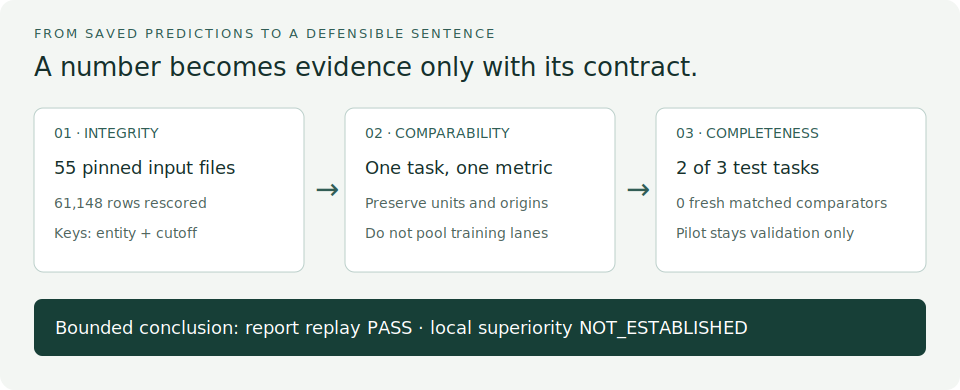<figcaption>The report checks integrity, comparability and completion separately. Passing one gate cannot substitute for the others.</figcaption></figure>

For **study-outcome reference test AUROC**, follow seeds 0–4 → five complete 20-epoch histories → first validation maximum in each history → 825 keyed test predictions per seed → five AUROCs → mean and sample SD. The course-selected seeds 10–14 follow a separate frozen selection procedure. Even though the selected learning rate equals the reference rate, their results stay in separate lanes. Choosing the nicer test mean now would change the reporting rule after seeing the outcome.

The replay verifies a frozen SHA256 manifest, deliberately reverses prediction order, realigns by both parts of the query key, recomputes metrics and checks the saved scores. Hash agreement establishes that the audited bytes have not changed; it does not establish that they are the paper authors' historical bytes. The [input manifest](https://avistian.github.io/relational/labs/evidence/l154/input-manifest.json) pins the actual files consumed.

**Lab task 1 — `summarize_runs`.** Require exactly the declared distinct seeds and one complete contract. Reject a partial epoch budget, mixed lane, changed candidate protocol, nonfinite metric or missing seed. Return the mean and **sample** SD using `ddof=1`. Run this function on the real rows, not just toy fixtures.



In [ ]:
# TODO: live reporting function used by the actual replay.
def summarize_runs(records, expected_seeds, contract):
    raise NotImplementedError("TODO: summarize_runs")

In [ ]:
# CHECK: adversarial contracts.
def rejects(fn):
    try:
        fn()
    except ValueError:
        return
    raise AssertionError('Invalid evidence accepted')
def fixture():
    contract = dict(task='toy', metric='MAE', unit='position', direction='lower',
                    split='test', population='keys:abc', protocol='recipe:a',
                    evaluation='full-population', lane='reference', epochs=10, n_queries=2, origin='LOCAL')
    records = [dict(contract, seed=s, status='COMPLETE', score=v)
               for s, v in [(0, 2.), (1, 4.), (2, 3.)]]
    return contract, records
def check_summary(fn):
    contract, rows = fixture()
    result = fn(list(reversed(rows)), [0, 1, 2], contract)
    assert result['mean'] == 3 and result['sample_sd'] == 1 and result['n_seeds'] == 3
    assert result['seeds'] == [0, 1, 2] and result['status'] == 'COMPLETE'
    rejects(lambda: fn(rows[:2], [0, 1, 2], contract))
    rejects(lambda: fn(rows + [rows[0]], [0, 1, 2], contract))
    rejects(lambda: fn(rows, [0, 0, 1], contract))
    for field, bad in [('protocol','other'),('lane','selected'),('epochs',1),
                       ('population','wrong'),('evaluation','sampled-candidates'),('split','val'),('n_queries',1),
                       ('status','PARTIAL_TIMING_PILOT'),('score',float('nan')),
                       ('score',float('inf')),('origin','PUBLISHED')]:
        changed = copy.deepcopy(rows); changed[0][field] = bad
        rejects(lambda: fn(changed, [0, 1, 2], contract))
    changed = dict(contract, metric='AUROC',unit='fraction',direction='higher')
    rejects(lambda: fn([dict(r,**changed) for r in rows], [0,1,2], changed))
check_summary(summarize_runs)
print("PASS summarize_runs")

## 3 · Read the measured table before interpreting it

| Task / metric | Local test mean ± sample SD | Completed seeds | Published comparator (context only) | Fresh FE / tree |
|---|---:|---:|---|---|
| rel-trial/study-outcome / AUROC | 69.2588 ± 0.7489% | 5/5 | Raw-table LightGBM: 70.090% | NOT_RUN / NOT_RUN |
| rel-f1/driver-position / MAE | 3.9708 ± 0.1626 positions | 5/5 | Raw-table LightGBM: 4.170 positions | NOT_RUN / NOT_RUN |
| rel-trial/site-sponsor-run / MAP@10 | NOT_RUN — INCOMPLETE | 0/5 | Past Visit (ranking heuristic): 17.310% | NOT_RUN / NOT_RUN |

AUROC and MAP are stored as fractions and displayed as percentages; MAE is measured in finishing-position units. A missing score is `null`/`NOT_RUN`, never zero. The published recommendation comparator shown here is **Past Visit**, not LightGBM or manual FE. The paper's GraphSAGE result is also distinct from its ID-GNN result. [Primary reading: RelBench v1 Tables 6–8](https://arxiv.org/html/2407.20060v1#A2.SS1).

<figure class="route-figure" tabindex="0">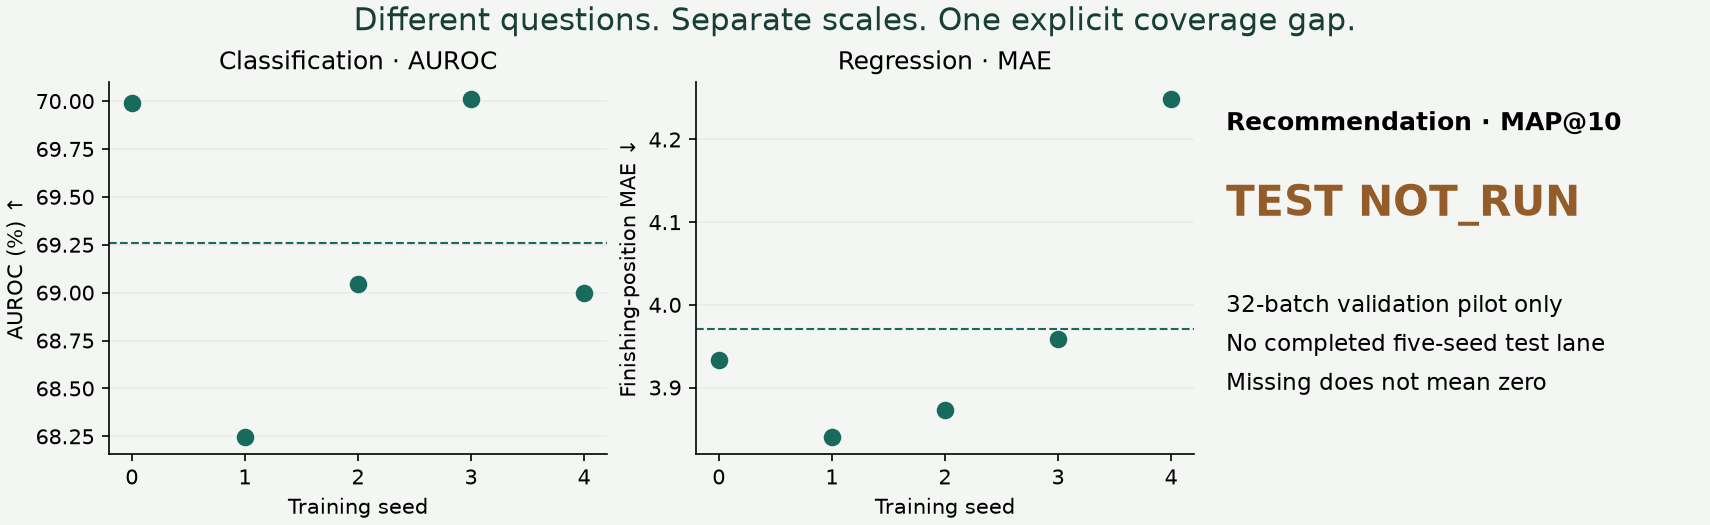<figcaption>Actual reference test scores, five seeds per completed task. Dashed lines are seed means; the third panel preserves the unrun test.</figcaption></figure>

**Replay result:** 61,148 rows independently rescored: 8,925 classification reference, 8,925 classification selected, 6,295 regression and 37,003 recommendation pilot rankings. All 15 completed-fit validation checkpoint selections passed. The primary test means are **69.2588% AUROC** and **3.9708 MAE**; both fall inside their previously frozen descriptive paper bands. That is not statistical equivalence or historical reproduction.

The separate classification course-selected lane is **68.4570 ± 1.3502% AUROC**. It does not become the reference result. Recommendation validation MAP@10 is **1.050815%** after 32 training batches; no test result exists. [Machine-readable replay](https://avistian.github.io/relational/labs/evidence/l154/report.json).

The five-seed SD describes variability over training seeds on the **same** evaluation population. It is not a confidence interval for performance on new databases. The L151 reference and course-selected seed sets are not paired runs merely because each has five scores. Do not compute a paired test by lining up their row numbers.

Our portfolio spans two databases and three selected tasks. It is not a random sample of all relational problems. The broad curriculum mentions five tasks; this synthesis covers the three entry artifacts prepared so far, and even the minimum three-completed-task requirement is unmet. Adding older results would require a new declared inclusion rule and comparability audit.



## 4 · A comparable difference needs a direction and an evidence label

Consider an explicitly **synthetic** MAE example: model 3, baseline 4. Benefit is `4 − 3 = +1 position`, or `100 × 1/4 = 25%` relative to that baseline. For an AUROC example, model .70 and baseline .60, benefit is `.70 − .60 = .10`, displayed as **10 percentage points**. A percentage-point difference is not a relative percentage improvement.

Use `model − baseline` for higher-is-better metrics and `baseline − model` for lower-is-better metrics. If the baseline is zero, the relative percentage is undefined. Even after orienting signs, one position and ten AUROC points cannot be averaged into a meaningful raw score. Relative changes remove physical units but still depend strongly on the chosen baseline; they do not make this incomplete portfolio suitable for a single headline average.

Predict before checking: does lower MAE than a published result establish a fresh matched win? Explain why the evidence origin matters.

Synthetic intervention: MAE 3 vs4 gives +1 position benefit. With a published comparator, this is context only; with a matched local comparator, it is a descriptive local difference. With incomplete runs, no final comparison is admitted. Try changing these fields in your function tests.

The widget uses fixtures, never edits the measured report. Switch evidence origin and completeness while holding scores fixed. Observe that the claim changes even when the numerical gap does not. Its “matched local” case assumes the same keyed population, evaluation protocol and a predeclared fair comparison. It remains descriptive, not a significance claim.

**Lab task 2 — `compare_entries`.** Verify task, split, units and direction. Local comparisons must also share the population and evaluation protocol. Compute the oriented gap, but label a published comparator `PUBLISHED_CONTEXT_ONLY` and leave its local winner `NOT_ESTABLISHED`. Raw-table trees and manually engineered relational features are different baselines; neither label is a synonym for the other. The paper describes its manual-FE study separately in [Section 6](https://arxiv.org/html/2407.20060v1#S6).

For the actual report, classification is numerically below the published raw-table tree result and regression is numerically above it in benefit direction. Neither comparison establishes a fresh local win or loss: we have not executed those baselines under matched local conditions. This is the specific gap L155's planned manual-FE comparison will address; human-effort measurements also need their own protocol.



In [ ]:
# TODO: live reporting function used by the actual replay.
def compare_entries(model, baseline):
    raise NotImplementedError("TODO: compare_entries")

In [ ]:
# CHECK: adversarial contracts.
def rejects(fn):
    try:
        fn()
    except ValueError:
        return
    raise AssertionError('Invalid evidence accepted')
def fixture():
    contract = dict(task='toy', metric='MAE', unit='position', direction='lower',
                    split='test', population='keys:abc', protocol='recipe:a',
                    evaluation='full-population', lane='reference', epochs=10, n_queries=2, origin='LOCAL')
    records = [dict(contract, seed=s, status='COMPLETE', score=v)
               for s, v in [(0, 2.), (1, 4.), (2, 3.)]]
    return contract, records
def check_comparison(fn):
    contract, _ = fixture()
    model = dict(contract, mean=3., status='COMPLETE', n_seeds=3)
    baseline = dict(model, mean=4., protocol='baseline:b', model='tree')
    r = fn(model, baseline)
    assert r['oriented_gap'] == 1 and r['scope'] == 'LOCAL_MATCHED_DESCRIPTIVE'
    assert r['winner'] == 'MODEL' and r['relative_percent'] == 25
    high = dict(model, metric='AUROC',unit='fraction',direction='higher',mean=.7)
    r = fn(high, dict(high,mean=.6))
    assert math.isclose(r['oriented_gap'],.1)
    assert fn(model,dict(baseline,mean=3))['winner']=='TIE'
    assert fn(model,dict(baseline,mean=0))['relative_percent'] is None
    paper = dict(baseline,origin='PUBLISHED',population='historical:unknown')
    r = fn(model,paper)
    assert r['scope']=='PUBLISHED_CONTEXT_ONLY' and r['winner']=='NOT_ESTABLISHED'
    for field,bad in [('task','other'),('metric','RMSE'),('unit','percent'),('split','val'),('direction','higher')]:
        rejects(lambda: fn(model,dict(baseline,**{field:bad})))
    rejects(lambda: fn(model,dict(baseline,population='different')))
    rejects(lambda: fn(model,dict(baseline,evaluation='sampled-candidates')))
    rejects(lambda: fn(model,dict(baseline,status='INCOMPLETE')))
    rejects(lambda: fn(model,dict(baseline,mean=float('nan'))))
check_comparison(compare_entries)
print("PASS compare_entries")

## 5 · Reproduce the report, preserve the unfinished experiment

**Named experiment:** `L154 RelBench portfolio evidence replay`. The default CPU lane verifies 55 pinned inputs and recomputes all saved validation/test predictions for the selected lanes. The executable functions are visible in the notebook and in [the reporting module](https://avistian.github.io/relational/labs/relkit/portfolio_l154.py); the [replay adapter](https://avistian.github.io/relational/labs/_replay_l154.py) supplies the real records.

```bash
# From the relational repository; no fitting, downloads or cloud dispatch.
.venv/bin/python labs/_check_l154.py
.venv/bin/python labs/_replay_l154.py
.venv/bin/python labs/_audit_l154.py
```

The standalone notebook embeds the same input packet and verifies its hashes in a newly created temporary directory. Its three learner functions are passed directly into the real replay. It exports your rebuilt report and leaves your defense pending. Re-executing an author packet demonstrates a reporting skill; it does not create new model fits or prove learner mastery automatically.

Full reproduction remains **task-specific**. The L151/L152 full-training recipes and evidence are linked in their ledgers. L153's full five-seed, 20-epoch, full-catalog recipe remains runnable, but its recorded budget decision is `STOP`: approximately **$41.23 compute before overhead**, against the approved $10 total cap. This projection is a scenario based on the pilot, not a guaranteed bill or a mathematical lower bound. L154 incurs **$0 additional cloud spend** and does not restart training.

The upstream label audits are retained. L154 does not rerun source SQL, graph construction, checkpoint inference or training. It uses L151's pinned task table, L152 targets already checked against the archived labels, and L153's pinned relevance sets. Source nonfinite-gradient observations remain unresolved. Temporal checks do not recover unobserved feature-arrival histories. Historical identity and feature-arrival legality remain `NOT_ESTABLISHED`.

**Lab task 3 — `portfolio_verdict`.** Count each required task once. Report two completed test tasks out of three and zero fresh matched comparator tasks. A published comparison cannot increase the local comparator count; a recommendation pilot cannot increase completed-test coverage. Emit `NOT_ESTABLISHED` for local superiority and keep learner status `PENDING_WRITTEN_DEFENSE`.



In [ ]:
# TODO: live reporting function used by the actual replay.
def portfolio_verdict(entries, comparisons, required_tasks):
    raise NotImplementedError("TODO: portfolio_verdict")

In [ ]:
# CHECK: adversarial contracts.
def rejects(fn):
    try:
        fn()
    except ValueError:
        return
    raise AssertionError('Invalid evidence accepted')
def fixture():
    contract = dict(task='toy', metric='MAE', unit='position', direction='lower',
                    split='test', population='keys:abc', protocol='recipe:a',
                    evaluation='full-population', lane='reference', epochs=10, n_queries=2, origin='LOCAL')
    records = [dict(contract, seed=s, status='COMPLETE', score=v)
               for s, v in [(0, 2.), (1, 4.), (2, 3.)]]
    return contract, records
def check_verdict(fn):
    entries=[dict(task=t,status='COMPLETE',origin='LOCAL',split='test') for t in ['a','b']]
    entries.append(dict(task='c',status='INCOMPLETE',origin='LOCAL',split='test'))
    comparisons=[dict(task='a',scope='PUBLISHED_CONTEXT_ONLY',winner='NOT_ESTABLISHED')]
    r=fn(entries,comparisons,['a','b','c'])
    assert r['complete_tasks']==2 and r['required_tasks']==3
    assert r['benchmark_coverage']=='INCOMPLETE' and r['matched_baseline_tasks']==0
    assert r['local_superiority']=='NOT_ESTABLISHED' and r['learner']=='PENDING_WRITTEN_DEFENSE'
    r=fn(entries[:2],[],['a','b','c'])
    assert r['missing_tasks']==['c']
    complete=copy.deepcopy(entries);complete[2]['status']='COMPLETE'
    comparisons=[dict(task=t,scope='LOCAL_MATCHED_DESCRIPTIVE',winner='MODEL') for t in ['a','b','c']]
    r=fn(complete,comparisons,['a','b','c'])
    assert r['benchmark_coverage']=='COMPLETE' and r['local_superiority']=='DESCRIPTIVE_WINS_ON_SELECTED_TASKS'
    assert r['learner']=='PENDING_WRITTEN_DEFENSE'
    rejects(lambda: fn(entries+[entries[0]],[],['a','b','c']))
    rejects(lambda: fn(entries,comparisons,['a','b','c']))  # pilot cannot support comparison
    rejects(lambda: fn(complete,comparisons+[comparisons[0]],['a','b','c']))
    rejects(lambda: fn([dict(entries[0],split='val')],[],['a']))
    rejects(lambda: fn(entries,[],['a','a','b']))
check_verdict(portfolio_verdict)
print("PASS portfolio_verdict")

### PROVIDED · Visible replay implementation

AUC uses average ranks for tied scores; MAE aligns predictions by full query keys; MAP iterates ranked candidates and uses the full relevant set. Selection histories and protocol fields are checked before aggregation. The following code reads only the temporary packet.

In [ ]:
def aligned_score(truth_keys, targets, prediction_keys, predictions, metric, catalog=None):
    truth_keys=[tuple(map(int,k)) for k in truth_keys]
    prediction_keys=[tuple(map(int,k)) for k in prediction_keys]
    if (not truth_keys or len(set(truth_keys))!=len(truth_keys) or
        len(set(prediction_keys))!=len(prediction_keys) or set(truth_keys)!=set(prediction_keys) or
        len(targets)!=len(truth_keys) or len(predictions)!=len(prediction_keys)):
        raise ValueError('Missing, duplicate or mismatched query keys')
    index={k:i for i,k in enumerate(prediction_keys)}
    pred=np.asarray(predictions)[[index[k] for k in truth_keys]]
    if not np.isfinite(pred).all():
        raise ValueError('Nonfinite predictions')
    if metric=='MAP@10':
        if pred.ndim!=2 or pred.shape[1]<1 or not catalog:
            raise ValueError('Missing candidate protocol')
        if not np.issubdtype(pred.dtype,np.integer) or pred.min()<0 or pred.max()>=catalog:
            raise ValueError('Invalid candidate identity')
        if any(len(set(row))!=len(row) for row in pred.tolist()):
            raise ValueError('Duplicate recommendations')
        values=[]
        for positives,ranking in zip(targets,pred.tolist()):
            relevant=set(positives)
            if not relevant or min(relevant)<0 or max(relevant)>=catalog:
                raise ValueError('Invalid relevance set')
            hits=0;total=0.
            for rank,item in enumerate(ranking,1):
                if item in relevant:
                    hits+=1;total+=hits/rank
            values.append(total/min(len(relevant),len(ranking)))
        return float(np.mean(values))
    y=np.asarray(targets,dtype=float)
    if pred.ndim!=1 or y.ndim!=1 or not np.isfinite(y).all():
        raise ValueError('Invalid scalar labels or predictions')
    if metric=='MAE':
        return float(np.mean(np.abs(pred.astype(float)-y)))
    if metric=='AUROC':
        if set(y.tolist())!={0.,1.}:
            raise ValueError('AUC requires both binary classes')
        order=np.argsort(pred,kind='stable');ranks=np.empty(len(pred),dtype=float)
        start=0
        while start<len(order):
            stop=start+1
            while stop<len(order) and pred[order[stop]]==pred[order[start]]:
                stop+=1
            ranks[order[start:stop]]=(start+1+stop)/2
            start=stop
        npos=int(y.sum());nneg=len(y)-npos
        return float((ranks[y==1].sum()-npos*(npos+1)/2)/(npos*nneg))
    raise ValueError('Unsupported metric')

def verify_inputs(root, manifest):
    root=Path(root).resolve()
    if not manifest.get('files'):
        raise ValueError('Empty input manifest')
    for relative,digest in manifest['files'].items():
        path=(root/relative).resolve()
        if not path.is_relative_to(root) or not path.is_file():
            raise ValueError('Missing or unsafe input: '+relative)
        if hashlib.sha256(path.read_bytes()).hexdigest()!=digest:
            raise ValueError('Changed frozen input: '+relative)
    return len(manifest['files'])

def replay(root, manifest, summarize=summarize_runs, compare=compare_entries, verdict=portfolio_verdict):
    """Recompute every saved split in each selected evidence lane, without refitting."""
    root=Path(root);verified=verify_inputs(root,manifest)
    def read(name):
        return json.loads((root/name).read_text())
    def keys(z,split,entity):
        return list(zip(map(int,z[split+'_'+entity]),map(int,z[split+'_time'])))
    def population(ks):
        return hashlib.sha256(json.dumps(sorted(ks),separators=(',',':')).encode()).hexdigest()
    def close(a,b):
        if abs(a-b)>1e-12:
            raise ValueError('Saved score disagrees with replay')
    counts={};summaries={};runs={};selection_checks=0
    base='evidence/l151';truth=np.load(root/base/'prepared/queries.npz',allow_pickle=False)
    frozen=read(base+'/frozen.json')
    if frozen['test_access'] or frozen['lr']!=max(frozen['candidates'],key=lambda x:(x['selection_auc'],-x['lr']))['lr']:
        raise ValueError('Invalid validation selection')
    ph=manifest['files']['sources/l151/protocol.json']
    for lane,prefix,seeds in [('reference','ref-',list(range(5))),('selected','selected-',list(range(10,15)))]:
        bucket={s:[] for s in ['val','test']};counts['l151_'+lane]=0
        for seed in seeds:
            directory=base+'/'+prefix+str(seed);r=read(directory+'/result.json')
            if (r['status']!='COMPLETE' or r['track']!=lane or r['seed']!=seed or
                r['epochs']!=20 or len(r['history'])!=20 or r['lr']!=frozen['lr']):
                raise ValueError('L151 incomplete or mixed lane')
            if r['best_epoch']!=1+int(np.argmax([h['val']['roc_auc'] for h in r['history']])):
                raise ValueError('L151 checkpoint selection')
            if r['temporal_audit']['future_violations']!=0:
                raise ValueError('Observed temporal violation')
            selection_checks+=1
            z=np.load(root/directory/'predictions.npz',allow_pickle=False)
            for split in bucket:
                tk=keys(truth,split,'study');pk=keys(z,split,'study')
                target_by_key=dict(zip(tk,truth[split+'_target'].tolist()))
                if any(target_by_key.get(k)!=float(y) for k,y in zip(pk,z[split+'_target'])):
                    raise ValueError('Classification target mismatch')
                score=aligned_score(tk,truth[split+'_target'],pk[::-1],z[split+'_pred'][::-1],'AUROC')
                close(score,r['scores'][split]['roc_auc']);counts['l151_'+lane]+=len(tk)
                contract=dict(task='rel-trial/study-outcome',metric='AUROC',unit='fraction',direction='higher',
                              split=split,population=population(tk),protocol=ph,lane=lane,epochs=20,
                              n_queries=len(tk),origin='LOCAL',evaluation='full-split-keyed-scalar')
                bucket[split].append(dict(contract,seed=seed,status='COMPLETE',score=score))
        runs['classification_'+lane]=bucket
        summaries['classification_'+lane]={s:summarize(rows,seeds,{k:v for k,v in rows[0].items() if k not in ('seed','status','score')}) for s,rows in bucket.items()}
    base='evidence/l152';truth=np.load(root/base/'paper/seed-0/predictions.npz',allow_pickle=False)
    labels=read(base+'/label-audit.json')
    if labels['status']!='PASS' or labels['independently_rebuilt_labels']!=8712:
        raise ValueError('Missing upstream label audit')
    bucket={s:[] for s in ['val','test']};counts['l152_reference']=0
    protocol=read('sources/l152/protocol.json');ph=manifest['files']['sources/l152/protocol.json']
    for seed in range(5):
        directory=base+'/paper/seed-'+str(seed);r=read(directory+'/result.json');done=read(directory+'/completed.json')
        if (done['status']!='COMPLETE' or done['seed']!=seed or r['seed']!=seed or
            r['epochs']!=10 or len(r['trace'])!=10 or r['protocol']!={
                'channels':protocol['channels'],'num_layers':protocol['layers'],
                'batch_size':protocol['batch_size'],'lr':protocol['lr'],'epochs':protocol['epochs'],
                'fanout':protocol['fanouts'],'aggr':protocol['aggr'],'temporal_strategy':'uniform'}):
            raise ValueError('L152 incomplete or changed recipe')
        if r['selected_epoch']!=min(r['trace'],key=lambda row:row['val_mae'])['epoch']:
            raise ValueError('L152 selection not first validation minimum')
        if read(directory+'/temporal-audit.json')['status']!='PASS':
            raise ValueError('Missing temporal audit')
        selection_checks+=1;z=np.load(root/directory/'predictions.npz',allow_pickle=False)
        for split in bucket:
            tk=keys(truth,split,'entity');pk=keys(z,split,'entity')
            target_by_key=dict(zip(tk,truth[split+'_target'].tolist()))
            if any(target_by_key.get(k)!=float(y) for k,y in zip(pk,z[split+'_target'])):
                raise ValueError('Regression target mismatch')
            if (hashlib.sha256(np.asarray(tk,dtype='<i8').tobytes()).hexdigest()!=labels['query_key_hashes'][split] or
                len(tk)!=labels['counts'][split]):
                raise ValueError('Regression population mismatch')
            score=aligned_score(tk,truth[split+'_target'],pk[::-1],z[split+'_pred'][::-1],'MAE')
            close(score,r['scores'][split]);counts['l152_reference']+=len(tk)
            contract=dict(task='rel-f1/driver-position',metric='MAE',unit='position',direction='lower',
                          split=split,population=population(tk),protocol=ph,lane='reference',epochs=10,
                          n_queries=len(tk),origin='LOCAL',evaluation='full-split-keyed-scalar')
            bucket[split].append(dict(contract,seed=seed,status='COMPLETE',score=score))
    runs['regression_reference']=bucket
    summaries['regression_reference']={s:summarize(rows,list(range(5)),{k:v for k,v in rows[0].items() if k not in ('seed','status','score')}) for s,rows in bucket.items()}
    base='evidence/l153';r=read(base+'/pilot/result.json');z=np.load(root/base/'pilot/predictions.npz',allow_pickle=False)
    truth=json.loads(gzip.decompress((root/base/'prepared/val-truth.json.gz').read_bytes()))
    if r['status']!='PARTIAL_TIMING_PILOT' or set(r['scores'])!={'val'} or any(k.startswith('test') for k in z.files):
        raise ValueError('Recommendation packet must remain a validation pilot')
    if r['protocol_hash']!=manifest['files']['sources/l153/protocol.json'] or z['val_pred'].shape!=(37003,10):
        raise ValueError('Changed ranking protocol')
    score=aligned_score([(t['entity'],t['time']) for t in truth],[t['positives'] for t in truth],
                        keys(z,'val','entity')[::-1],z['val_pred'][::-1],'MAP@10',53241)
    close(score,r['scores']['val']);counts['l153_pilot']=len(truth)
    incomplete=dict(task='rel-trial/site-sponsor-run',metric='MAP@10',unit='fraction',direction='higher',
                    split='test',population='NOT_EVALUATED',protocol=r['protocol_hash'],lane='reference',
                    epochs=20,n_queries=27428,origin='LOCAL',evaluation='full-catalog:53241@10',status='INCOMPLETE',n_seeds=0,
                    mean=None,sample_sd=None)
    pilot=dict(task=incomplete['task'],split='val',status='PARTIAL_TIMING_PILOT',mean=score,
               n_queries=len(truth),catalog=53241,training_batches=32,seed=0)
    entries=[summaries['classification_reference']['test'],summaries['regression_reference']['test'],incomplete]
    context=read('evidence/l154/published-context.json');comparisons=[];paper_replay=[]
    for entry in entries:
        if entry['status']!='COMPLETE':
            continue
        row=context['tasks'][entry['task']]
        published=dict(entry,origin='PUBLISHED',population='HISTORICAL_NOT_ESTABLISHED',mean=row['baseline_mean'])
        c=compare(entry,published);c.update(baseline=row['baseline'],source=row['source']);comparisons.append(c)
        target=dict(published,mean=row['model_mean'])
        comparison=compare(entry,target)
        paper_replay.append(dict(task=entry['task'],gap=comparison['oriented_gap'],
                                 status='CLOSE' if abs(entry['mean']-row['model_mean'])<=row['tolerance'] else 'OUTSIDE_TOLERANCE',
                                 tolerance=row['tolerance'],meaning='Descriptive frozen band; not equivalence'))
    result=verdict(entries,comparisons,[e['task'] for e in entries])
    return dict(experiment='L154 RelBench portfolio evidence replay',status='PASS',input_files_verified=verified,
                input_manifest_sha256=hashlib.sha256(json.dumps(manifest,sort_keys=True).encode()).hexdigest(),
                prediction_rows_rescored=counts,total_prediction_rows=sum(counts.values()),
                validation_selection_checks=selection_checks,entries=entries,summaries=summaries,runs=runs,
                pilot=pilot,published_context=context,comparisons=comparisons,paper_replay=paper_replay,
                verdict=result,recommendation_cost_decision=read(base+'/cost-decision.json'),
                fresh_manual_fe='NOT_RUN',fresh_tree_baselines='NOT_RUN',full_paper='NOT_RUN',
                historical_identity='NOT_ESTABLISHED',feature_arrival_legality='NOT_ESTABLISHED',
                new_training='NOT_RUN',additional_cloud_spend_usd=0,
                target_label_boundary='L151 pinned task table; L152 targets from seed0 packet previously checked against archive SQL; L153 pinned relevance sets. No new source-SQL execution.',
                selection_boundary='Reference classification selected by design, not test score; course-selected lane remains separate. No retuning.',
                gradient_boundary='Source nonfinite-gradient observations in L151-L153 persist; rescoring cannot certify optimization health.',
                live_colab='NOT_CHECKED',deployment='NOT_CHECKED')

def render_report(report):
    """Same data feeds the lesson table and portable report."""
    lines=['# RelBench portfolio synthesis','',
           'Named experiment: **'+report['experiment']+'**. This is saved-prediction replay; no new fits.',
           '', '| Task / metric | Local test mean ± sample SD | Completed seeds | Published comparator (context only) | Fresh FE / tree |',
           '|---|---:|---:|---|---|']
    for entry in report['entries']:
        row=report['published_context']['tasks'][entry['task']];scale=100 if entry['unit']=='fraction' else 1
        suffix='%' if scale==100 else ' positions'
        local=(f"{entry['mean']*scale:.4f} ± {entry['sample_sd']*scale:.4f}{suffix}" if entry['status']=='COMPLETE' else 'NOT_RUN — INCOMPLETE')
        lines.append(f"| {entry['task']} / {entry['metric']} | {local} | {entry['n_seeds']}/5 | {row['baseline']}: {row['baseline_mean']*scale:.3f}{suffix} | NOT_RUN / NOT_RUN |")
    v=report['verdict'];lines+=['',f"**Coverage: {v['complete_tasks']}/{v['required_tasks']} tasks; {v['matched_baseline_tasks']} fresh matched comparator tasks.** Local superiority: **{v['local_superiority']}**.",
        '', 'The recommendation pilot evaluated validation only: '+f"{report['pilot']['mean']*100:.6f}% MAP@10 on {report['pilot']['n_queries']:,} queries. This is not a third completed test result.",
        '', '## Within-task descriptive context']
    for c in report['comparisons']:
        scale=100 if c['unit']=='fraction' else 1;unit='percentage points' if scale==100 else 'positions'
        lines.append(f"- {c['task']}: oriented benefit relative to the published baseline {c['oriented_gap']*scale:+.4f} {unit}. {c['scope']}; local win NOT_ESTABLISHED.")
    selected=report['summaries']['classification_selected']['test']
    lines+=['',f"Separate course-selected classification lane: {100*selected['mean']:.4f} ± {100*selected['sample_sd']:.4f}% AUROC, seeds10–14. Never pooled with reference seeds0–4.",
        '', '## Evidence and limits',
        f"Independently rescored {report['total_prediction_rows']:,} prediction rows; checked {report['validation_selection_checks']} validation-selected checkpoints and {report['input_files_verified']} frozen input files.",
        '', 'No arithmetic mean across AUROC, MAE and MAP; no win rate with missing matched baselines. Sample SD describes training-seed variability on the same fixed test population; it is not uncertainty across databases.',
        '', report['target_label_boundary'], '', report['selection_boundary'], '', report['gradient_boundary'],
        '', 'Full selected recommendation reproduction INCOMPLETE. Whole paper / fresh FE / fresh trees NOT_RUN. Historical identity and feature-arrival legality NOT_ESTABLISHED. Learner PENDING_WRITTEN_DEFENSE. Live Colab / deployment NOT_CHECKED.',
        '', 'Additional cloud spend: USD0. Replay does not count historical training costs again.',
        '', '## Sources',
        '[RelBench v1 Tables 6–8](https://arxiv.org/html/2407.20060v1#A2.SS1); upstream reproduction ledgers: [L151](../../l151-reproduction.md), [L152](../../l152-reproduction.md), [L153](../../l153-reproduction.md).',
        '', '## Learner defense',
        'PENDING_WRITTEN_DEFENSE — explain coverage, baseline identity, a within-task difference, seed uncertainty and the missing experiment before claiming completion.']
    return '\n'.join(lines)+'\n'

In [ ]:
# CHECK: these exact learner functions construct the real measured report.
report=replay(REPLAY_ROOT,MANIFEST,summarize=summarize_runs,compare=compare_entries,verdict=portfolio_verdict)
assert report['total_prediction_rows']==61148
assert report['verdict']['complete_tasks']==2
assert report['verdict']['matched_baseline_tasks']==0
assert report['verdict']['local_superiority']=='NOT_ESTABLISHED'
display(Markdown(render_report(report)))


## 6 · Exit: defend the missing cell

[Open the worked notebook](https://avistian.github.io/relational/labs/html/0154-portfolio-synthesis.html) · [Download student lab](https://avistian.github.io/relational/labs/0154-portfolio-synthesis.ipynb) · [Teacher solution](https://avistian.github.io/relational/labs/solutions/0154-portfolio-synthesis.ipynb) · [Generated report](https://avistian.github.io/relational/labs/evidence/l154/report.md) · [Report JSON](https://avistian.github.io/relational/labs/evidence/l154/report.json) · [Quick reference](https://avistian.github.io/relational/reference/portfolio-synthesis.html) · [Reproduction contract](https://avistian.github.io/relational/labs/l154-reproduction.md).

Write **250–400 words** answering: What has been reproduced? Which baseline has actually been run locally? Why can you not average the three metrics? What does seed SD quantify? Which missing experiment would change your conclusion? Include one measured number and its unit, and defend why the third test cell stays empty.

Score each dimension 0–2: provenance, comparable units, completeness, uncertainty, bounded conclusion. Readiness requires **8/10 with no zero**, reviewed by the teaching agent. Passing author checks does not grant this score. Tomorrow, reconstruct the two difference formulas from memory; in one week, rebuild the coverage verdict without looking at the report.

Write the defense before reviewing the teacher answer. Submit it to the teaching agent.

Ask the agent follow-up questions about any unclear comparison, rejected row or evidence boundary. Bring your exported report and written defense so we can assess your reasoning, not only whether the notebook ran.


In [ ]:
# EXIT: your evidence replay and your reasoning have separate statuses.
WRITTEN_DEFENSE = ""  # Write 250–400 words; submit for review, never auto-award mastery.
export=dict(report,written_defense=WRITTEN_DEFENSE,learner='PENDING_WRITTEN_DEFENSE')
Path('l154-portfolio-report.json').write_text(json.dumps(export,indent=2)+'\n')
Path('l154-portfolio-report.md').write_text(render_report(report)+'\n'+WRITTEN_DEFENSE)
Path('l154-report.json').write_text(json.dumps(dict(status='PASS',prediction_rows=report['total_prediction_rows'],verdict=report['verdict'],additional_cloud_spend_usd=0),indent=2))
print('Exported l154-portfolio-report.json and .md; defense PENDING_WRITTEN_DEFENSE')
workspace.cleanup()
